In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


In [3]:
#loading the dataset
df=pd.read_csv(r"c:\Users\samaira\Downloads\Synergy_TP\task_11\data\Crop_recommendation.csv")

#checking the first 5 rows of the dataset
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df['label'].value_counts())



    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB
None
                 N      

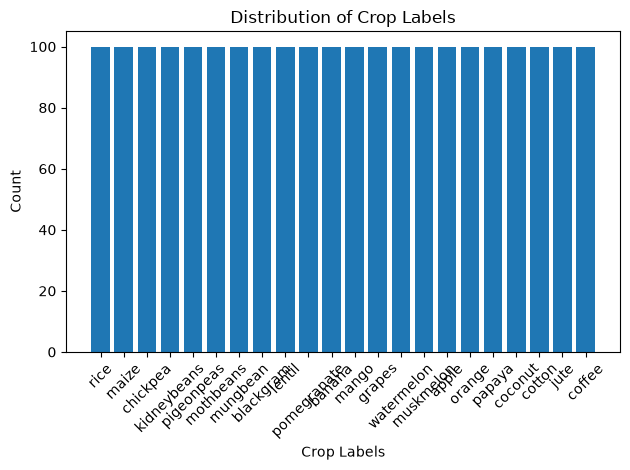

In [4]:
target="label"
selected_features=['N','P','K','temperature','humidity','ph','rainfall']
plt.bar(df[target].value_counts().index, df[target].value_counts().values)
plt.xlabel('Crop Labels')
plt.ylabel('Count')
plt.title('Distribution of Crop Labels')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#the distribution of all the crops is uniform equal to 100.

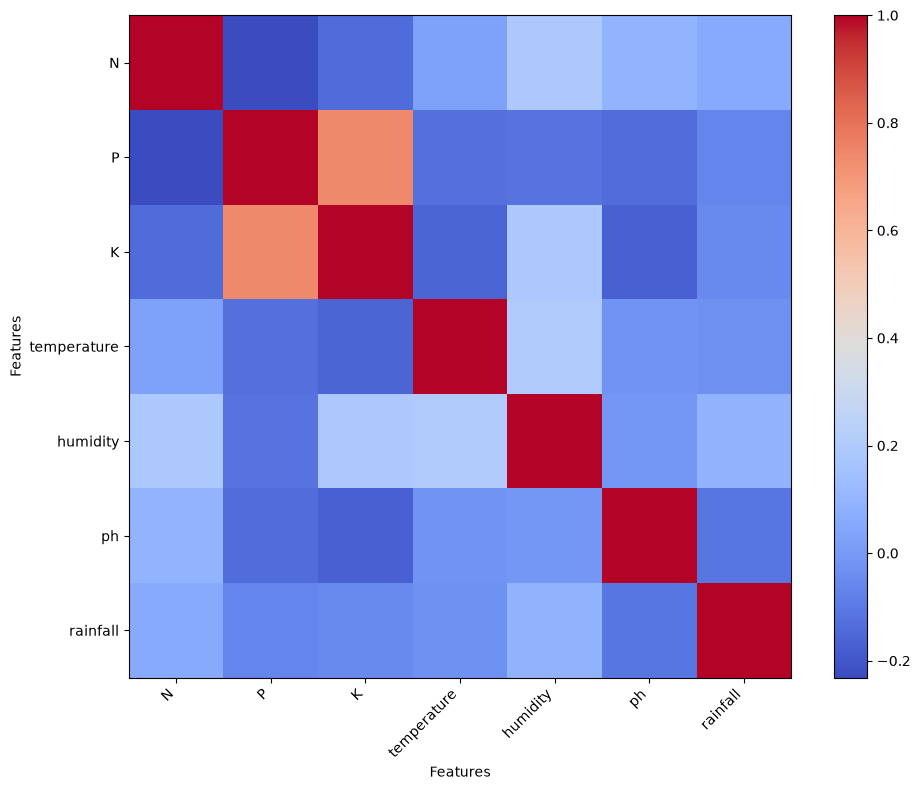

In [5]:
correlation_matrix = df[selected_features].corr()
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap='coolwarm')
plt.xlabel('Features')
plt.ylabel('Features')
plt.colorbar()
plt.xticks(range(len(selected_features)), selected_features, rotation=45, ha='right')
plt.yticks(range(len(selected_features)), selected_features)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
X=df[selected_features]
y=df[target]

# First split: 70% train, 30% temp (which becomes val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

# Second split: divide the 30% temp into 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (1540, 7) Val: (330, 7) Test: (330, 7)


In [7]:
#dummy baseline model
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

y_val_pred_dummy = dummy.predict(X_val)
print("Dummy baseline accuracy:", accuracy_score(y_val, y_val_pred_dummy))
print("Dummy baseline F1 (macro):", f1_score(y_val, y_val_pred_dummy, average='macro'))



Dummy baseline accuracy: 0.045454545454545456
Dummy baseline F1 (macro): 0.003952569169960474


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

logreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
logreg_pipe.fit(X_train, y_train)
y_val_pred_lr = logreg_pipe.predict(X_val)
print("LogReg val accuracy:", accuracy_score(y_val, y_val_pred_lr))
print("LogReg val F1 (macro):", f1_score(y_val, y_val_pred_lr, average='macro'))


LogReg val accuracy: 0.9666666666666667
LogReg val F1 (macro): 0.9664550974693558


In [9]:
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])
knn_pipe.fit(X_train, y_train)
y_val_pred_knn = knn_pipe.predict(X_val)
print("KNN val accuracy:", accuracy_score(y_val, y_val_pred_knn))
print("KNN val F1 (macro):", f1_score(y_val, y_val_pred_knn, average='macro'))

KNN val accuracy: 0.9848484848484849
KNN val F1 (macro): 0.9848113163254987


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=10)
dt.fit(X_train, y_train)
y_val_pred_dt = dt.predict(X_val)
print("Decision Tree val accuracy:", accuracy_score(y_val, y_val_pred_dt))
print("Decision Tree val F1 (macro):", f1_score(y_val, y_val_pred_dt, average='macro'))

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_val_pred_rf = rf.predict(X_val)
print("Random Forest val accuracy:", accuracy_score(y_val, y_val_pred_rf))
print("Random Forest val F1 (macro):", f1_score(y_val, y_val_pred_rf, average='macro'))

Decision Tree val accuracy: 0.9757575757575757
Decision Tree val F1 (macro): 0.9754283513814307
Random Forest val accuracy: 0.990909090909091
Random Forest val F1 (macro): 0.9908989786631611


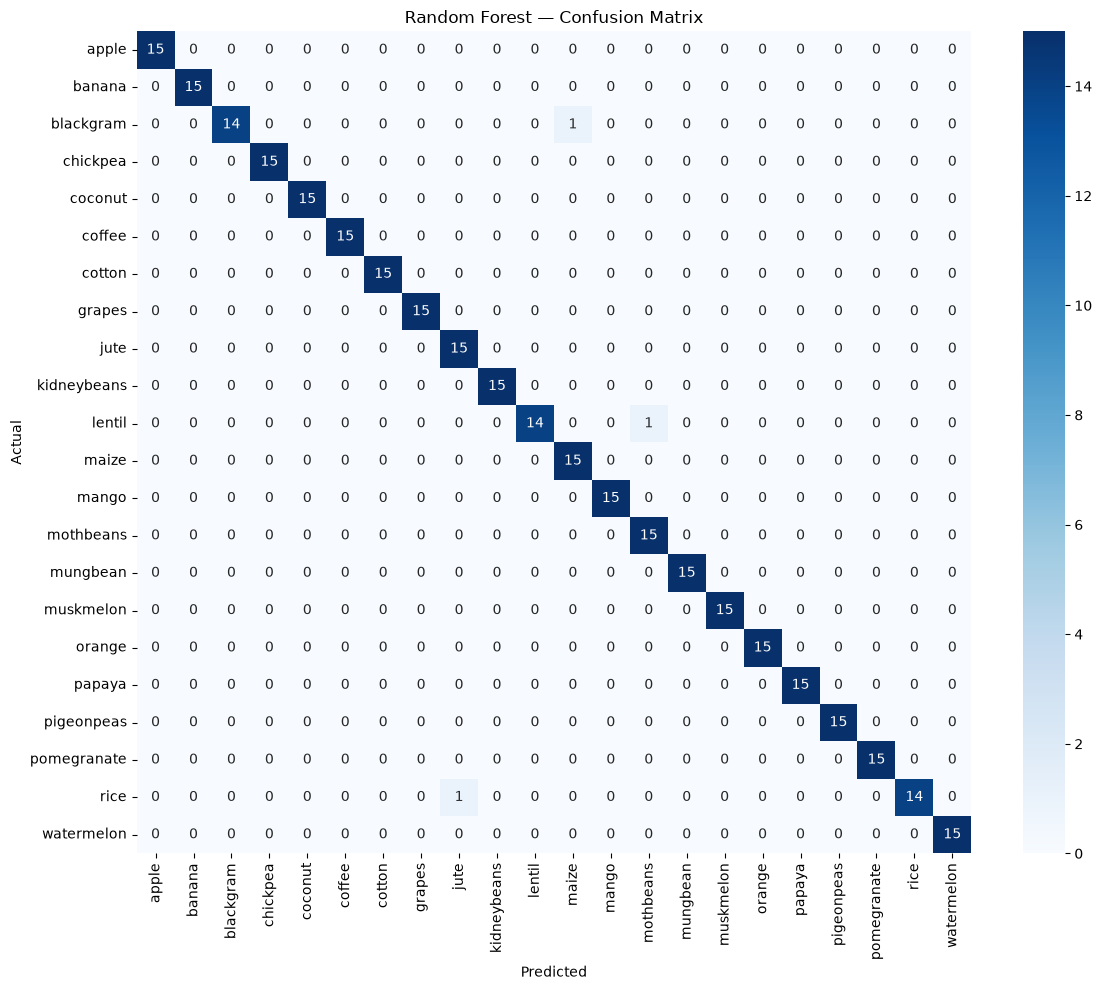

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred_rf, labels=rf.classes_)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest — Confusion Matrix')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', dpi=150)
plt.show()

                 Model  Accuracy  F1 (macro)
0       Dummy Baseline    0.0455      0.0040
1  Logistic Regression    0.9667      0.9665
2                  KNN    0.9848      0.9848
3        Decision Tree    0.9758      0.9754
4        Random Forest    0.9909      0.9909


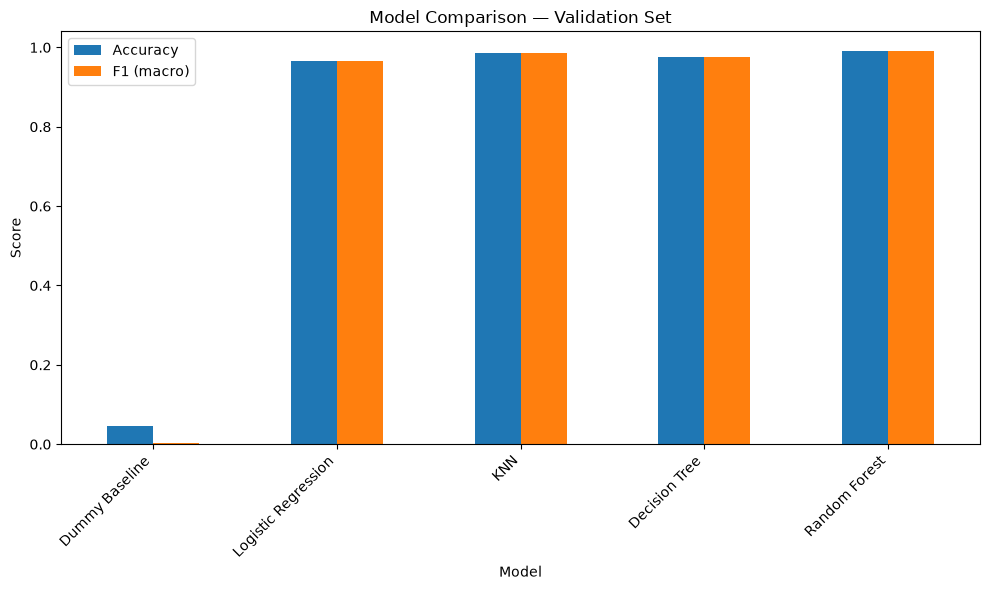

In [12]:
results = pd.DataFrame({
    'Model': ['Dummy Baseline', 'Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest'],
    'Accuracy': [0.0455, 0.9667, 0.9848, 0.9758, 0.9909],
    'F1 (macro)': [0.0040, 0.9665, 0.9848, 0.9754, 0.9909]
})

print(results)

results.set_index('Model')[['Accuracy', 'F1 (macro)']].plot(kind='bar', figsize=(10,6))
plt.ylabel('Score')
plt.title('Model Comparison — Validation Set')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [13]:
from sklearn.metrics import classification_report

y_test_pred_rf = rf.predict(X_test)

print("Final Test Accuracy:", accuracy_score(y_test, y_test_pred_rf))
print("Final Test F1 (macro):", f1_score(y_test, y_test_pred_rf, average='macro'))
print("\nFull classification report:\n")
print(classification_report(y_test, y_test_pred_rf))

Final Test Accuracy: 0.996969696969697
Final Test F1 (macro): 0.9969663262210537

Full classification report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        15
      banana       1.00      1.00      1.00        15
   blackgram       1.00      1.00      1.00        15
    chickpea       1.00      1.00      1.00        15
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        15
      cotton       1.00      1.00      1.00        15
      grapes       1.00      1.00      1.00        15
        jute       0.94      1.00      0.97        15
 kidneybeans       1.00      1.00      1.00        15
      lentil       1.00      1.00      1.00        15
       maize       1.00      1.00      1.00        15
       mango       1.00      1.00      1.00        15
   mothbeans       1.00      1.00      1.00        15
    mungbean       1.00      1.00      1.00        15
   muskmelon       1.00 

In [14]:
from sklearn.pipeline import Pipeline
import joblib

final_pipeline = Pipeline([
    ('model', RandomForestClassifier(n_estimators=200, random_state=42))
])

# Retrain on train+val combined
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])
final_pipeline.fit(X_trainval, y_trainval)

joblib.dump(final_pipeline, 'crop_recommendation_model.joblib')
print("Model saved.")

Model saved.


In [16]:
import sys
import joblib
import pandas as pd
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    model = joblib.load('crop_recommendation_model.joblib')
    
    input_df = pd.DataFrame([{
        'N': N, 'P': P, 'K': K,
        'temperature': temperature, 'humidity': humidity,
        'ph': ph, 'rainfall': rainfall
    }])
    
    prediction = model.predict(input_df)[0]
    return prediction
'''
if __name__ == "__main__":
    if len(sys.argv) != 8:
        print("Usage: python predict.py <N> <P> <K> <temperature> <humidity> <ph> <rainfall>")
        sys.exit(1)
    
    N, P, K, temperature, humidity, ph, rainfall = map(float, sys.argv[1:8])
    
    result = predict_crop(N, P, K, temperature, humidity, ph, rainfall)
    print(f"Recommended crop: {result}")'''

'\nif __name__ == "__main__":\n    if len(sys.argv) != 8:\n        print("Usage: python predict.py <N> <P> <K> <temperature> <humidity> <ph> <rainfall>")\n        sys.exit(1)\n\n    N, P, K, temperature, humidity, ph, rainfall = map(float, sys.argv[1:8])\n\n    result = predict_crop(N, P, K, temperature, humidity, ph, rainfall)\n    print(f"Recommended crop: {result}")'